# FlightsPriceModel — Training & Error Analysis

This notebook builds directly on the exploratory work in **FlightsData.ipynb**.
It reuses the same dataset and core preprocessing assumptions from the EDA notebook, then adds model training and prediction error analysis.

## 1. Imports
Load libraries for modeling, preprocessing, metrics, and visualization.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load Data
Use the same training dataset used in FlightsData.ipynb.

In [3]:
df = pd.read_excel('data/Data_Train.xlsx')
print(f'Loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Loaded: 10683 rows, 11 columns


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


## 3. Preprocessing (Aligned with FlightsData)
Replicate key cleaning and feature engineering used in FlightsData.ipynb:
- drop missing rows
- parse journey date
- create duration in minutes
- map total stops to numeric

In [4]:
df = df.dropna().copy()

df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y')
df['Journey_Month'] = df['Date_of_Journey'].dt.month
df['Journey_Day'] = df['Date_of_Journey'].dt.day

def parse_duration(duration):
    total_min = 0
    if isinstance(duration, str):
        if 'h' in duration:
            total_min += int(duration.split('h')[0].strip()) * 60
            duration = duration.split('h')[1]
        if 'm' in duration:
            total_min += int(duration.split('m')[0].strip())
    return total_min

df['Duration_minutes'] = df['Duration'].apply(parse_duration)

stops_map = {'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}
df['Total_Stops_num'] = df['Total_Stops'].map(stops_map)

# Extra time-based features for modeling
df['Dep_Hour'] = pd.to_datetime(df['Dep_Time']).dt.hour
df['Dep_Minute'] = pd.to_datetime(df['Dep_Time']).dt.minute
df['Arrival_Hour'] = pd.to_datetime(df['Arrival_Time']).dt.hour
df['Arrival_Minute'] = pd.to_datetime(df['Arrival_Time']).dt.minute

df[['Price', 'Duration_minutes', 'Total_Stops_num', 'Journey_Month', 'Journey_Day']].describe()

,Price,Duration_minutes,Total_Stops_num,Journey_Month,Journey_Day
count,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000
mean,9087.214567,643.020502,0.824190,4.708575,13.509081
std,4611.548810,507.830133,0.675229,1.164408,8.479363
min,1759.000000,5.000000,0.000000,3.000000,1.000000
25%,5277.000000,170.000000,0.000000,3.000000,6.000000
50%,8372.000000,520.000000,1.000000,5.000000,12.000000
75%,12373.000000,930.000000,1.000000,6.000000,21.000000
max,79512.000000,2860.000000,4.000000,6.000000,27.000000


## 4. Train/Test Split and Model Pipelines

In [5]:
target_col = 'Price'
drop_cols = ['Price', 'Date_of_Journey', 'Duration', 'Route', 'Additional_Info']

X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df[target_col].copy()

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)
print('Categorical features:', len(categorical_features), '| Numeric features:', len(numeric_features))

Train shape: (8545, 14) | Test shape: (2137, 14)
Categorical features: 6 | Numeric features: 8


## 5. Train and Compare Models

In [6]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denom = np.where(y_true == 0, 1, y_true)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

results = []
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'MAPE_%': mape
    })
    trained_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values(by='RMSE').reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2,MAPE_%
0,RandomForest,1142.966073,1950.863190,0.823492,12.561075
1,GradientBoosting,1554.629878,2198.783559,0.775780,18.208353
2,LinearRegression,1592.223899,2423.877268,0.727522,19.095912


## 6. Select Best Model

In [7]:
best_model_name = results_df.loc[0, 'Model']
best_model = trained_pipelines[best_model_name]
y_pred = best_model.predict(X_test)

print(f'Best model by RMSE: {best_model_name}')

Best model by RMSE: RandomForest


## 7. Prediction Error Analysis
Visual diagnostics to understand model error behavior on unseen test data.

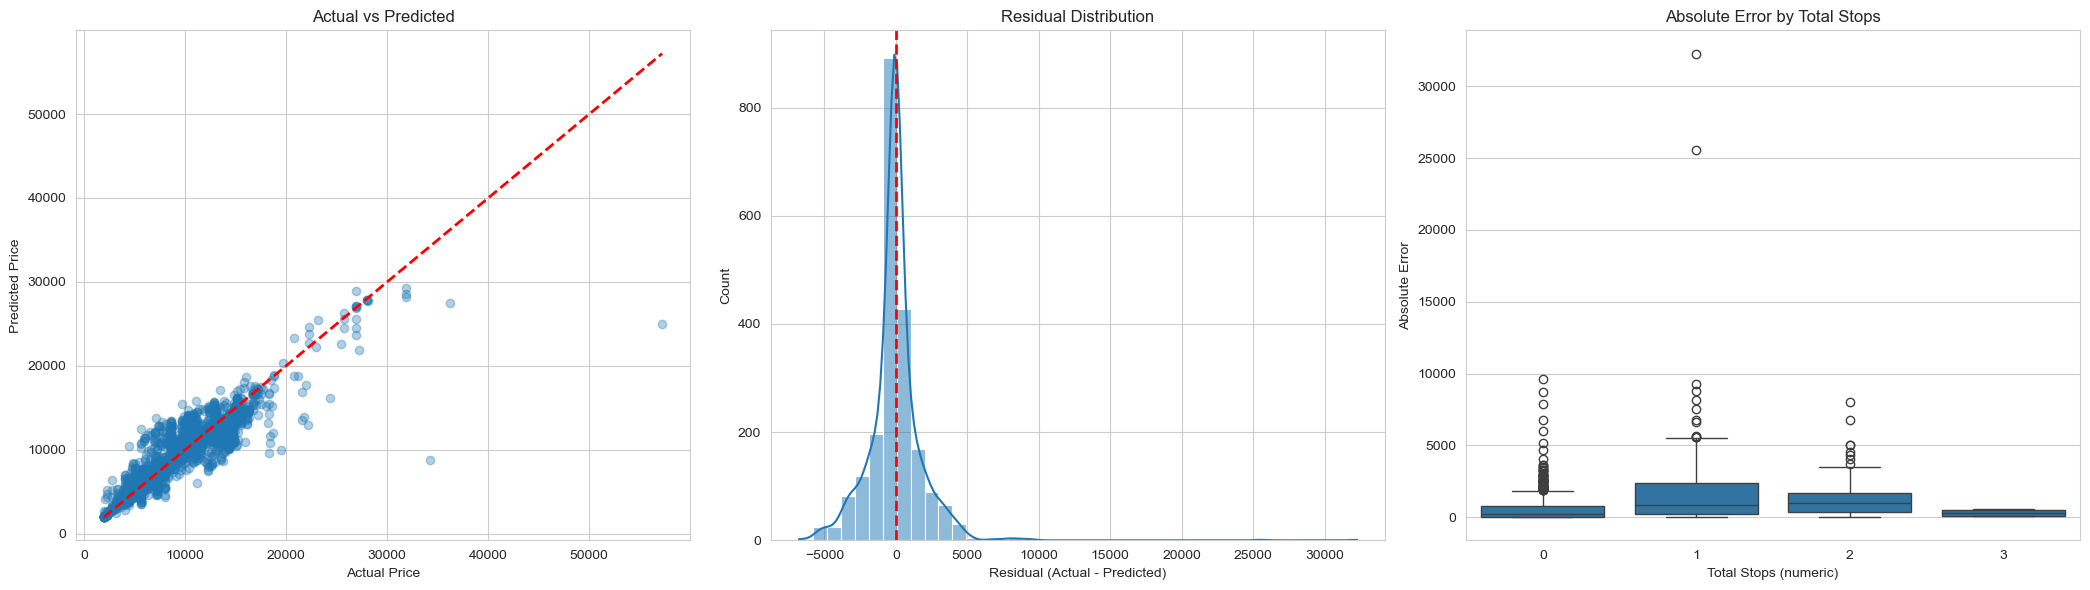

In [8]:
error_df = X_test.copy()
error_df['Actual_Price'] = y_test.values
error_df['Predicted_Price'] = y_pred
error_df['Residual'] = error_df['Actual_Price'] - error_df['Predicted_Price']
error_df['Abs_Error'] = np.abs(error_df['Residual'])

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# 1) Actual vs Predicted
axes[0].scatter(error_df['Actual_Price'], error_df['Predicted_Price'], alpha=0.35)
min_price = min(error_df['Actual_Price'].min(), error_df['Predicted_Price'].min())
max_price = max(error_df['Actual_Price'].max(), error_df['Predicted_Price'].max())
axes[0].plot([min_price, max_price], [min_price, max_price], 'r--', linewidth=2)
axes[0].set_title('Actual vs Predicted')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')

# 2) Residual distribution
sns.histplot(error_df['Residual'], kde=True, bins=40, ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (Actual - Predicted)')

# 3) Absolute error by number of stops
if 'Total_Stops_num' in error_df.columns:
    sns.boxplot(data=error_df, x='Total_Stops_num', y='Abs_Error', ax=axes[2])
    axes[2].set_title('Absolute Error by Total Stops')
    axes[2].set_xlabel('Total Stops (numeric)')
    axes[2].set_ylabel('Absolute Error')
else:
    axes[2].text(0.5, 0.5, 'Total_Stops_num not available', ha='center', va='center')
    axes[2].set_title('Absolute Error by Total Stops')

plt.tight_layout()
plt.show()

## 8. Largest Prediction Errors

In [9]:
top_error_cols = [
    c for c in ['Airline', 'Source', 'Destination', 'Total_Stops', 'Duration_minutes', 'Actual_Price', 'Predicted_Price', 'Residual', 'Abs_Error']
    if c in error_df.columns
]

error_df.sort_values('Abs_Error', ascending=False)[top_error_cols].head(15)

,Airline,Source,Destination,Total_Stops,Duration_minutes,Actual_Price,Predicted_Price,Residual,Abs_Error
10364,Jet Airways Business,Banglore,New Delhi,1 stop,280,57209,24929.516667,32279.483333,32279.483333
6991,Multiple carriers,Delhi,Cochin,1 stop,760,34273,8725.106667,25547.893333,25547.893333
2628,Air India,Banglore,New Delhi,non-stop,165,19508,9911.560278,9596.439722,9596.439722
5850,IndiGo,Banglore,New Delhi,1 stop,300,22153,12902.840000,9250.160000,9250.160000
5719,Jet Airways,Banglore,New Delhi,1 stop,435,36235,27458.896667,8776.103333,8776.103333
5308,Jet Airways,Banglore,New Delhi,non-stop,160,18308,9595.851389,8712.148611,8712.148611
10160,Multiple carriers,Delhi,Cochin,1 stop,515,24318,16127.855000,8190.145000,8190.145000
5980,Air India,Delhi,Cochin,2 stops,1820,21571,13581.852222,7989.147778,7989.147778
9303,Vistara,Banglore,New Delhi,non-stop,160,21730,13853.856667,7876.143333,7876.143333
1835,Jet Airways,Delhi,Cochin,1 stop,620,18371,10854.333611,7516.666389,7516.666389


## 9. Findings — Business Understanding

The business problem is to estimate a fair and competitive flight fare for a given itinerary (source, destination, travel date, airline, stops, and duration) before the ticket is priced or purchased.



Accurate fare prediction helps key stakeholders:

- **Customers** compare options and identify potential overpricing.

- **Airlines/Travel Platforms** optimize pricing strategy to improve bookings, revenue, and customer trust.

- **Operations/Planning Teams** monitor how route structure, duration, and stops influence expected price.



From a business perspective, this model is a decision-support tool: it does not replace market pricing engines, but provides a reliable benchmark price range. Prediction error analysis is important because it shows where the model is less reliable (for example, specific routes or stop patterns), which informs risk-aware pricing and future data/model improvements.


## 10. Next Steps

- Persist the best model for inference (e.g., joblib).

- Align this notebook with any future feature updates made in FlightsData.ipynb.

- Add cross-validation and hyperparameter tuning for stronger generalization.